Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


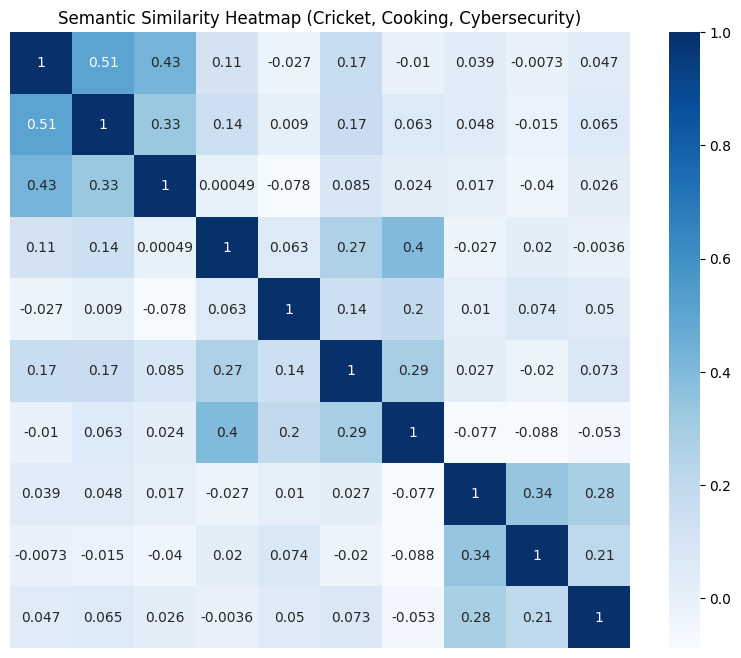


Query: The bowler took three wickets in one over
------------------------------
Score: 0.5740 | Sentence: The fast bowler delivered a perfect yorker at the death overs.
Score: 0.5300 | Sentence: The batsman hit a magnificent century to lead his team to victory.


In [3]:
# 1. Install and Import Libraries
!pip install -U sentence-transformers seaborn matplotlib

from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# 2. Define 10 sentences across 3 topics
# Topics: Cricket (3), Cooking (4), Cybersecurity (3)
sentences = [
    "The batsman hit a magnificent century to lead his team to victory.",
    "The fast bowler delivered a perfect yorker at the death overs.",
    "Cricket fans around the world are excited for the upcoming World Cup.",
    "Always sauté the onions until they turn golden brown for the best flavor.",
    "Baking bread requires a precise balance of flour, water, and yeast.",
    "Slow-cooking the meat makes it incredibly tender and juicy.",
    "Add a pinch of salt and black pepper to season the dish perfectly.",
    "Multi-factor authentication is essential for securing your online accounts.",
    "Phishing attacks often involve deceptive emails to steal sensitive data.",
    "A strong firewall is the first line of defense against network intruders."
]

# 3. Generate Embeddings using all-MiniLM-L6-v2
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

# 4. Compute and Display 10x10 Cosine Similarity Matrix
# We compute similarity between all pairs of sentences
cosine_scores = util.cos_sim(embeddings, embeddings)

# Convert to numpy for visualization
matrix = cosine_scores.cpu().numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap='Blues', xticklabels=False, yticklabels=False)
plt.title("Semantic Similarity Heatmap (Cricket, Cooking, Cybersecurity)")
plt.show()

# 5. Search Query
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

# Compute similarity of query against the corpus
hits = util.semantic_search(query_embedding, embeddings, top_k=2)

print(f"\nQuery: {query}")
print("-" * 30)
for hit in hits[0]:
    print(f"Score: {hit['score']:.4f} | Sentence: {sentences[hit['corpus_id']]}")